# TD 3 | Étude de la marge EGT d'un turboréacteur

---

Objectifs du TD :

* pratiquer sur un premier use case concret d'analyse de données de moteurs d'avion
* fonctions glissantes pandas (_rolling_)
* régression linéaire

---

La table fournie contient les données moteurs disposant de l'information "marge EGT" (egthdm) issue
des rapports ACARS. Il s'agit donc uniquement de rapports extraits au décollage (TAKEOFF). On a
récupéré l'ensemble des rapports des moteurs livrés depuis avril 2016.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Chargement et nettoyage des données

#### 1.1. Chargez les données ACARS à l'aide de la méthode pandas `read_excel`. Explorez les propriétés générales du jeu de données.

Fichier de données : `./data/accars_b.xlsx`.

In [ ]:
import os
os.chdir('MACS3_Stats_TDs')

In [2]:
data = pd.read_excel("../data/accars_b.xlsx")

#### 1.2. Y a-t-il des valeurs manquantes ? Si oui, décrivez leur répartition et affichez le nombre de valeurs manquantes par colonne sous forme d'un bar plot.

In [3]:
data.isna().any()

flight_phase                   False
engine_number                  False
engine_type                    False
aircraft_number                False
engine_position                False
airline_classif_environment     True
brat                            True
cas                             True
cycles                          True
delfn                           True
deln1                           True
dtamb                           True
egthdm                          True
iai                             True
iaie1                           True
iaie2                           True
iaiwg                           True
ibe1                           False
ibe2                           False
ivs12                          False
pcn1k                           True
sloatl                          True
tsih                            True
vbvpos                          True
wbe                             True
yn1mod                          True
zalt                            True
z

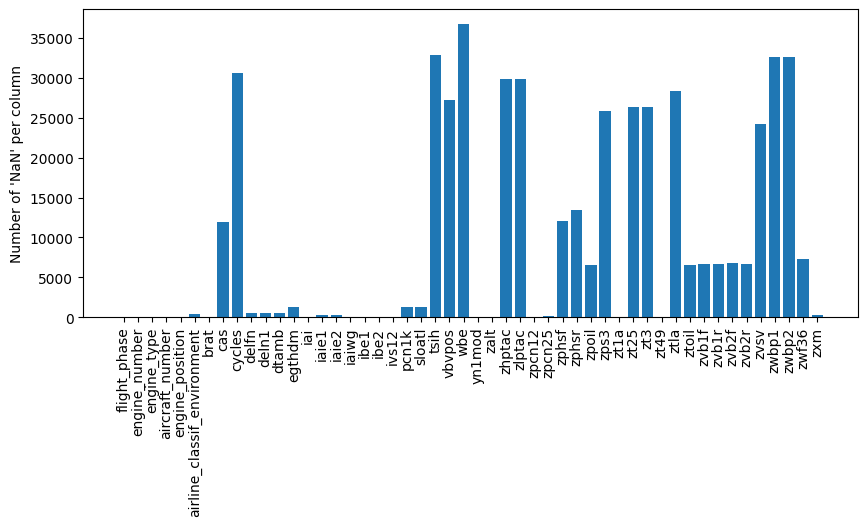

In [4]:
plt.figure(figsize=(10,4))
plt.bar(data.columns, data.isna().sum(axis=0))
plt.xticks(rotation=90)
plt.ylabel("Number of 'NaN' per column")

plt.show()

#### 1.3. Ne gardez que les lignes où le nombre de cycles (variable `cycles`) et la marge EGT (variable `egthdm`) sont présentes.

In [5]:
data = data[ data["cycles"].notna() & data["egthdm"].notna() ]

#### 1.4. Affichez les différents types de moteurs (indice : utilisez la méthode `unique()`).

In [6]:
print("The different (unique) engine types are the following:", data.engine_type.unique())

The different (unique) engine types are the following: [10  5  7]


#### 1.5. Sélectionnez uniquement les moteurs de type 10. Combien y a-t-il d'avions distincts ? Combien de vols par avion ? (attention : il y a 2 moteurs sur un avion)

In [7]:
data_engine_10 = data[data.engine_type == 10]

print("The aircrapt (numbers) with engine type '10' are the following:", data_engine_10.aircraft_number.unique())
print("This number of unique aircrafts with engine type '10' is:", len(data_engine_10.aircraft_number.unique()))

The aircrapt (numbers) with engine type '10' are the following: [192  14  11 190 191]
This number of unique aircrafts with engine type '10' is: 5


In [8]:
data_engine_10.flight_phase.unique()

array(['TAKEOFF'], dtype=object)

In [9]:
grouped = data_engine_10.groupby(["aircraft_number"]).size()/2

print("The number of flights per aircraft (number) are as follows:", grouped)

The number of flights per aircraft (number) are as follows: aircraft_number
11      17.0
14      97.0
190    110.0
191      6.0
192    126.0
dtype: float64


## 2. Étude de la marge EGT de l'avion 190

#### 2.1. Récupérez les variables `engine_number`, nombre de cycles (`cycles`) et marge EGT (`egthdm`) pour l'avion identifié par le numéro 190.

In [10]:
data_aircraft_190 = data[data.aircraft_number == 190][["engine_number", "cycles", "egthdm"]]
data_aircraft_190

,engine_number,cycles,egthdm
11398,179,98.0,52.0118
11399,180,69.0,57.6415
11400,180,75.0,48.7217
11755,179,0.0,37.6572
11756,179,1.0,37.2208
...,...,...,...
45809,180,48.0,51.9444
45810,180,58.0,59.0032
46111,179,163.0,45.8711
46411,179,30.0,56.5585


#### 2.2. Affichez la courbe de l'évolution de la marge EGT au cours du temps pour les deux moteurs de l'avion, sur deux graphes séparés et en prenant soin d'ajouter des légendes.

/tmp/ipykernel_28672/2874838269.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend()


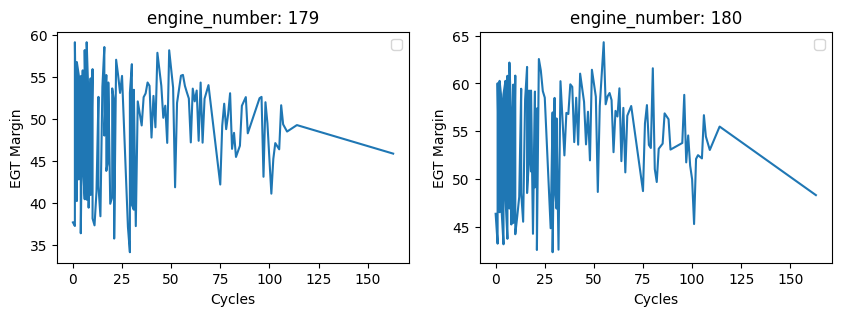

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))

for i, engine_number in enumerate(data_aircraft_190.engine_number.unique()):
    data_aircraft_190_ = data_aircraft_190[data_aircraft_190.engine_number==engine_number]
    data_aircraft_190_ = data_aircraft_190_.sort_values(by=['cycles'])

    ax[i].plot(data_aircraft_190_.cycles, data_aircraft_190_.egthdm)
    ax[i].set_title("engine_number: {}".format(engine_number))
    ax[i].set_xlabel("Cycles")
    ax[i].set_ylabel("EGT Margin")
    ax[i].legend()

plt.show()

#### 2.3. Pour la suite, on ne s'intéresse qu'au moteur 179. Quel est le nombre de vols manquant dans les données ?

In [12]:
data_engine_179 = data_aircraft_190[data_aircraft_190.engine_number==179]

max_cicle = data_engine_179.cycles.max()
print("The maximun 'cycles' number for the engine 179 is:", max_cicle)

unique_cicles = len(data_engine_179.cycles.unique())
print("On the other side, the number of unique 'cycles' number is:", unique_cicles)

missing_number = max_cicle - unique_cicles
print("The difference suggets that (at least) {} flights are missing".format(missing_number))


The maximun 'cycles' number for the engine 179 is: 163.0
On the other side, the number of unique 'cycles' number is: 91
The difference suggets that (at least) 72.0 flights are missing


#### 2.4. Nettoyage de la marge EGT

On constate que sur un même cycle, il peut y avoir 2 valeurs de la variable `egthdm` mesurées. On ne souhaite garder que la plus grande des deux, et avoir une seule ligne par cycle, afin que l'on puisse utiliser le nombre de cycles comme index. Enfin, on veut compléter l'index pour les vols manquants, en remplissant les lignes par `NaN`. Pour cela, effectuez l'exercice suivant:

1. Utilisez une aggrégation pour obtenir la plus grande valeur à chaque cycle et stockez le résultat dans une Series pandas appelée 'egt'.
2. Ré-indexez le DataFrame pour avoir une ligne pour tout nombre de cycles (indice : passez par la méthode reindex).

In [13]:
egt = data_engine_179.groupby(["cycles"]).aggregate({"egthdm":"max"}).egthdm

new_index = pd.RangeIndex(egt.index.min(), egt.index.max()+1)
egt = egt.reindex(new_index)

egt

0      37.6572
1      59.1796
2      56.8104
3      55.2263
4      55.1283
        ...   
159        NaN
160        NaN
161        NaN
162        NaN
163    45.8711
Name: egthdm, Length: 164, dtype: float64

#### 2.5. On souhaite lisser les valeurs et se débarasser des outliers à l'aide d'une médiane glissante sur 15 cycles. Affichez sur un même graphe la marge EGT brute (points) et la marge lissée (ligne).
http://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.rolling.html#pandas.Series.rolling

Utilisez une fenêtre glissante de taille 15 cycles, avec un minimum de 3 observations non-nulles par fenêtre (paramètre `min_periods`).

In [14]:
egt_smoothed = egt.rolling(window=15, min_periods=3).median()

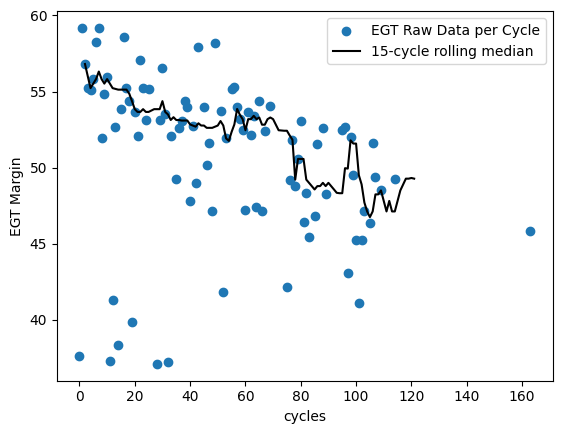

In [15]:
plt.scatter(egt.index, egt, label='EGT Raw Data per Cycle')
plt.plot(egt_smoothed.index, egt_smoothed, color="k", label="15-cycle rolling median")
plt.xlabel("cycles")
plt.ylabel("EGT Margin")

plt.legend()
plt.show()

#### 2.6. Nettoyage de la marge EGT lissée

La marge EGT ne peut être que décroissante, sauf en cas de nettoyage moteur (waterwash) ou peut-être à cause d'éléments extérieurs, on va donc éviter de tenir compte des remontées de marge et ne prendre en considération que les points descendants. Cette estimation est pessimiste mais évite de prendre en compte ces facteurs extérieurs.

1. Calculez une série ne contenant que les valeurs décroissantes de la amrge EGT lissée.
2. Sur le graphique précédent, ajoutez ces points par-dessus la courbe.

In [99]:
egt_smoothed_dec = egt_smoothed.copy()

last_value = 1+egt_smoothed.dropna().max()
for i, value_i in enumerate(egt_smoothed):
    if pd.isna(value_i) or value_i >= last_value:
        egt_smoothed_dec[i] = pd.NA
    else:
        last_value = egt_smoothed[i]

egt_smoothed_dec = egt_smoothed_dec.dropna()

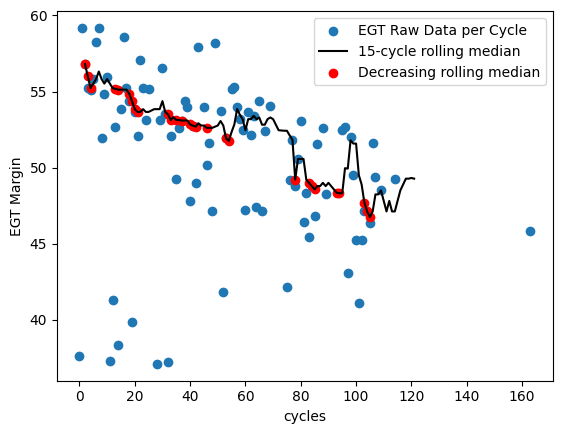

In [100]:
plt.scatter(egt.index, egt, label='EGT Raw Data per Cycle')
plt.plot(egt_smoothed.index, egt_smoothed, color="k", label="15-cycle rolling median")
plt.scatter(egt_smoothed_dec.index, egt_smoothed_dec, color="r", label="Decreasing rolling median")
plt.xlabel("cycles")
plt.ylabel("EGT Margin")

plt.legend()
plt.show()

#### 2.7. Estimation de la pente de la marge EGT

La pente de la marge EGT est un indicateur très intéressant de l'usure du moteur. On l'estime par régression linéaire par rapport au nombre de cycles. Pour cela, on utilise les points conservés précédemment qui constituent une estimation pessimiste.

Pour la régression linéaire, on utilisera le modèle `LinearRegression` de scikit-learn. Son utilisation est similaire aux autres modèles de scikit-learn :
```python
lr = LinearRegression()
model = lr.fit(X, y)
```

1. Apprenez un modèle `LinearRegression` sur les données calculées précédemment. Affichez les coefficients et l'ordonnée à l'origine (_intercept_) du modèle obtenu. Les valeurs sont-elles cohérentes ? (indices : pour passer d'un objet pandas (DataFrame ou Series) à un array numpy, utilisez la propriété `values`)
2. Tracez la droite obtenue sur le graphe précédent.

In [101]:
from sklearn.linear_model import LinearRegression

In [102]:
X_egt_smoothed_dec = egt_smoothed_dec.index.values.reshape(-1, 1)
y_egt_smoothed_dec = egt_smoothed_dec.values.reshape(-1, 1)

lr = LinearRegression()
lr.fit(X_egt_smoothed_dec, y_egt_smoothed_dec)

# predict using complete data
X_egt_index = egt.index.values.reshape(-1, 1)
y_pred = lr.predict(X_egt_index)

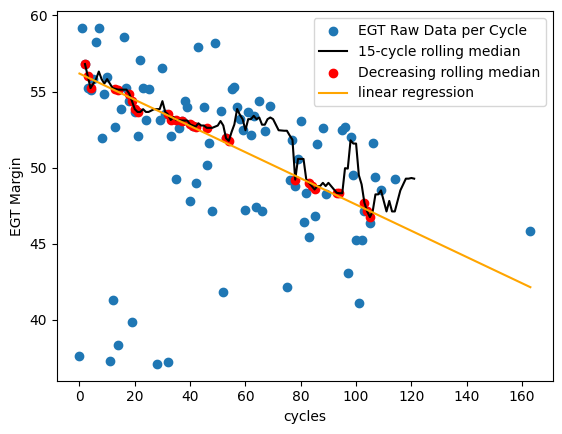

In [103]:
plt.scatter(egt.index, egt, label='EGT Raw Data per Cycle')
plt.plot(egt_smoothed.index, egt_smoothed, color="k", label="15-cycle rolling median")
plt.scatter(egt_smoothed_dec.index, egt_smoothed_dec, color="r", label="Decreasing rolling median")
plt.plot(egt.index, y_pred, color="orange", label="linear regression")

plt.xlabel("cycles")
plt.ylabel("EGT Margin")

plt.legend()
plt.show()

### 3. Écriture d'une fonction de calcul de la pente EGT pour tous les moteurs

Tout d'abord, bravo si vous êtes arrivés jusque là ! Toutes les opérations que l'on a effectuées ont permis d'estimer la pente de la marge EGT du moteur 179 de l'avion 190 de type 10, et donc son usure. Maintenant, on souhaite répéter ce processus sur tous les moteurs ! Pour cela, il faudra créer une fonction Python générique, prenant en entrée l'ensemble du jeu de données ACARS et produisant en sortie l'ensemble des pentes/intercept des modèles de régression linéaire appris pour chaque moteur.

L'un des intérêts est de pouvoir prédire l'usure des moteurs, après un nombre de cycles donné.

Voici le squelette de la fonction à écrire (en ré-utilisant et adaptant tout les morceaux de code précédents) :

```python
def regress_egt_margin(df_acars):
    ...
    return df_regress_models # Contient les pentes et intercept pour tous les moteurs
```

In [ ]:
def get_drecreasing_sequence(sequence):
    egt_smoothed_dec = sequence.copy()

    last_value = 1+sequence.dropna().max()
    for i, value_i in enumerate(sequence):
        if pd.isna(value_i) or value_i >= last_value:
            egt_smoothed_dec[i] = pd.NA
        else:
            last_value = value_i

    return egt_smoothed_dec.dropna()


def regress_egt_margin(df_acars):
    # only line where both cycles and egthdm are available
    data = df_acars[ df_acars["cycles"].notna() & df_acars["egthdm"].notna()]

    # the output will be on the form:
    #   engine_number (index): slopes, intercepts
    unique_engine_numbers = data.engine_number.unique()
    engine_slopes_intercepts = [] 
    for engine_number in unique_engine_numbers:
        data_engine_number = data[data.engine_number==engine_number]
        
        # only max egt and reindex
        egt = data_engine_number.groupby(["cycles"]).aggregate({"egthdm":"max"}).egthdm

        new_index = pd.RangeIndex(egt.index.min(), egt.index.max()+1)
        egt = egt.reindex(new_index)

        # smooth the sequence
        egt_smoothed = egt.rolling(window=15, min_periods=3).median()

        # only decreasing
        egt_smoothed_dec = get_drecreasing_sequence(egt_smoothed)

        # linear regression
        X_egt_smoothed_dec = egt_smoothed_dec.index.values.reshape(-1, 1)
        y_egt_smoothed_dec = egt_smoothed_dec.values.reshape(-1, 1)

        try:
            lr = LinearRegression()
            lr.fit(X_egt_smoothed_dec, y_egt_smoothed_dec)

            # save results
            coef_inter = [lr.coef_[0][0], lr.intercept_[0]]
        except Exception as e:
            # message
            # print(f"warning: can't compute egt_margin for engine_number: {engine_number}")
            # print(" error message:", e)
            coef_inter = [pd.NA, pd.NA]

        engine_slopes_intercepts.append(coef_inter)
    
    # return as dataframe
    idx = pd.Index(unique_engine_numbers, name='engine_number')
    egt_margins = pd.DataFrame(engine_slopes_intercepts,
        columns=["slope", "inter"], index=idx)
    
    return egt_margins

In [ ]:
df_acars = pd.read_excel("../data/accars_b.xlsx")
regressions = regress_egt_margin(df_acars)

regressions

,slope,inter
engine_number,,
186,-0.034208,58.139929
187,-0.040681,58.925632
184,-0.043789,44.38192
188,-0.035708,58.821227
1,-0.101226,92.676394
...,...,...
25,0.0,107.487
15,0.261857,111.930571
81,-0.147747,110.055802


### 4. Comparaison de l'usure des 3 types de moteurs

#### 4.1. Prédiction de la marge EGT au 150ème par type de moteur

1. Pour chaque moteur, utilisez son modèle de régression pour prédire la valeur de la marge EGT après 150 cycles d'utilisation (indice : méthode `apply`).
2. Représentez ces valeurs par type moteur sur un box plot. Décrivez le résultat obtenu.
3. Calculez la moyenne de la marge au 150ème cycle par type de moteur. Quel type de moteur a la plus grande marge moyenne après 150 cycles ?

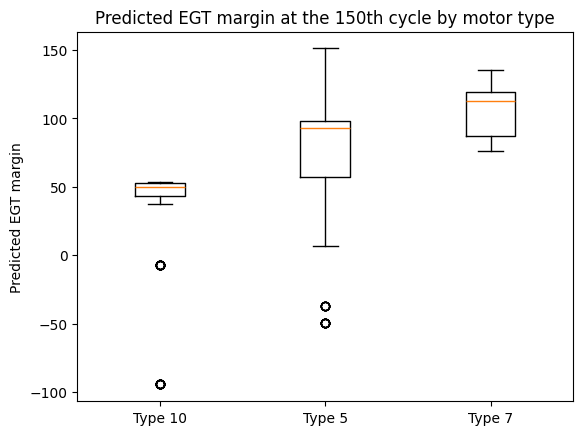

In [ ]:
# compute EGT margins
egt_margin_150 = regressions.slope*150 + regressions.inter

data = df_acars[df_acars["cycles"].notna() & df_acars["egthdm"].notna()]

# separate by engine_type
egt_margin_by_type = []
egt_average_by_type = []

engine_types = data.engine_type.unique()
for engine_type in engine_types:
    # compute engine numbers
    engine_numbers_type = data[data.engine_type == engine_type].engine_number

    # saving predicted EGT and average
    egt_margin_type = egt_margin_150.loc[engine_numbers_type].dropna()
    egt_margin_by_type.append(egt_margin_type.values)
    egt_average_by_type.append(egt_margin_type.mean())

plt.boxplot(egt_margin_by_type, tick_labels=[f"Type {t}" for t in engine_types])
plt.title("Predicted EGT margin at the 150th cycle by motor type")
plt.ylabel("Predicted EGT margin")
plt.show()

We observe that the engines of type 10 tend to present a predicted EGT margin of around 50, with little varation (except for outliers). Thus, the prediction seems reliable for future assessments.

Alernativelly, motors of type 5 present a higher average and considerable variation. This might suggest that the evolution (over cycles) of this type of motor is less predictable.

FInally, motors of type 7 present the hightest predicted EGT of all, with small variation and no outliers observed.

In [ ]:
print("The avegare EGT after 150 cycle per type:")
for engine_type, average_egt in zip(engine_types, egt_average_by_type):
    print(f" type: {engine_type}, average: {average_egt}")

The avegare EGT after 150 cycle per type:
 type: 10, average: 43.86357957619856
 type: 5, average: 82.49895302980057
 type: 7, average: 104.40330880764647


As seen above, and observed previosly, on average, after 150 cycles, motors of type 7 present the highest EGT margins.

#### 4.3. Vitesse de décroissance de la marge EGT par type de moteur

La pente de la marge EGT correspond à sa vitesse de décroissance par cycle.

1. Quelle est son unité ?
2. Représentez ces valeurs par type de moteur sur un boxplot. Décrivez le résultat obtenu.
3. Calculez moyenne de la pente par type de moteur. Quel type de moteur a la plus faible vitesse de décroissance et donc la plus faible vitesse d'usure ?

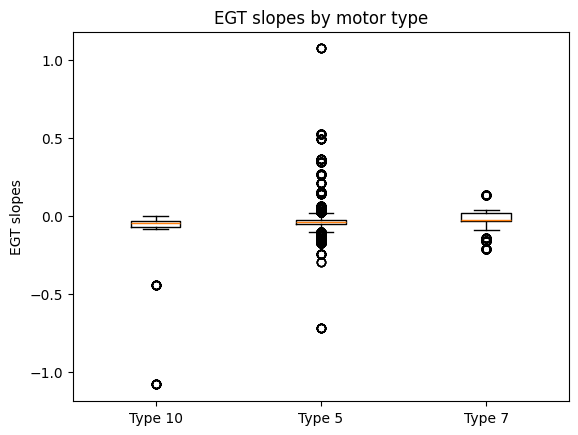

In [199]:
data = df_acars[df_acars["cycles"].notna() & df_acars["egthdm"].notna()]

# separate by engine_type
slopes_by_type = []
slopes_average_by_type = []

engine_types = data.engine_type.unique()
for engine_type in engine_types:
    # compute engine numbers
    engine_numbers_type = data[data.engine_type == engine_type].engine_number

    # saving slopes
    slopes_type = regressions.loc[engine_numbers_type].slope.dropna()
    slopes_by_type.append(slopes_type)
    slopes_average_by_type.append(slopes_type.mean())
    

plt.boxplot(slopes_by_type, tick_labels=[f"Type {t}" for t in engine_types])
plt.title("EGT slopes by motor type")
plt.ylabel("EGT slopes")
plt.show()

As expexted, engines of type 10 present smaller slope variations, unconsidering outliers. Engines of type 7 are similar, but a slightly greater variation.

On the other side, engines or type 5 have considerably greater slop variations, which suggest that this engine type is less predictable over time.

In [202]:
print("The avegare slopes per type:")
for engine_type, slope in zip(engine_types, slopes_average_by_type):
    print(f" type: {engine_type}, average slope: {slope}")

The avegare slopes per type:
 type: 10, average slope: -0.08503490828854889
 type: 5, average slope: -0.03814246602520299
 type: 7, average slope: -0.02818934402122265


As can be seen above, the engine type with the lowest decline rate (that is, the smaller slope in module) is the type 7. This was predictable from previous analisys.